1.BUSINESS UNDERSTANDING

Business Objective/Problem: Predict whether a customer will stop doing business with SyriaTel “soon” (binary: churn = 1, stay = 0).

Audience: Telecom business managers who want to reduce customer churn and retain revenue.

Key question: Are there predictable patterns ( usage, customer service calls,ETC) that signal churn?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE


2.DATA CLEANING AND PROCESSING

In [2]:
df = pd.read_csv("bigml_59c28831336c6604c800002a.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [4]:
df.columns

Index(['state', 'account length', 'area code', 'phone number',
       'international plan', 'voice mail plan', 'number vmail messages',
       'total day minutes', 'total day calls', 'total day charge',
       'total eve minutes', 'total eve calls', 'total eve charge',
       'total night minutes', 'total night calls', 'total night charge',
       'total intl minutes', 'total intl calls', 'total intl charge',
       'customer service calls', 'churn'],
      dtype='object')

In [5]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.rename(columns={
    'total_ev_e_charge': 'total_eve_charge',
    'to_total_intl_minutes': 'total_intl_minutes',
    'customer_service_ca_lls': 'customer_service_calls'
}, inplace=True)


In [6]:
#Drop useless / redundant columns
# Drop phone number (unique identifier) and area code (low value)
df.drop(['phone_number', 'area_code'], axis=1, inplace=True, errors='ignore')
df.head()

,state,account_length,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,KS,128,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [7]:
# Drop charge columns to avoid multicollinearity (keep minutes)
charge_cols = ['total_day_charge', 'total_eve_charge', 'total_night_charge', 'total_intl_charge']
df.drop(charge_cols, axis=1, inplace=True)

In [8]:
# Encode binary categorical variables

df['international_plan'] = (df['international_plan'] == 'yes').astype(int)
df['voice_mail_plan'] = (df['voice_mail_plan'] == 'yes').astype(int)

In [9]:
# Handle ‘state’ – target encoding (mean churn per state)
state_churn_mean = df.groupby('state')['churn'].mean()
df['state_churn_rate'] = df['state'].map(state_churn_mean)
df.drop('state', axis=1, inplace=True)

3.TRAIN/TEST SPLIT AND CLASS IMBALANCES

In [10]:
X = df.drop('churn', axis=1)
y = df['churn']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [12]:
# Apply SMOTE on training set only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


In [13]:
# Scale features (for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

4.MODELING: I.LOGISTIC REGRESSION 

In [14]:
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train_res)

y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]


In [15]:
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.3f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

       False       0.94      0.72      0.81       570
        True       0.30      0.72      0.43        97

    accuracy                           0.72       667
   macro avg       0.62      0.72      0.62       667
weighted avg       0.85      0.72      0.76       667

ROC-AUC: 0.787


MODELING: II.DECISION TREE

In [16]:
dt = DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
dt.fit(X_train_res, y_train_res)   

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]


In [17]:
print("\n=== Decision Tree ===")
print(classification_report(y_test, y_pred_dt))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_dt):.3f}")


=== Decision Tree ===
              precision    recall  f1-score   support

       False       0.93      0.92      0.93       570
        True       0.57      0.59      0.58        97

    accuracy                           0.88       667
   macro avg       0.75      0.76      0.75       667
weighted avg       0.88      0.88      0.88       667

ROC-AUC: 0.797


5.BUSINESS EVALUATION AND MODEL COMPARISON
  :CONFUSION MATRICES

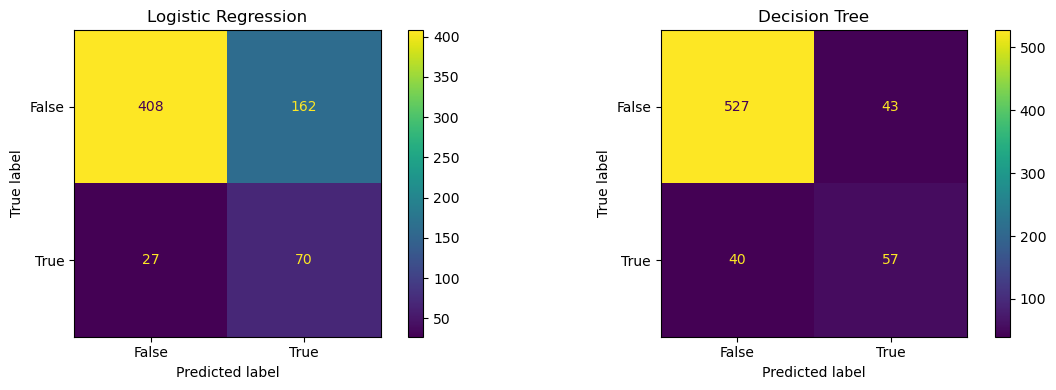

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0])
axes[0].set_title("Logistic Regression")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, ax=axes[1])
axes[1].set_title("Decision Tree")
plt.tight_layout()
plt.show()

6.BUSINESS INSIGHTS (EDA)

I.DECISION TREE

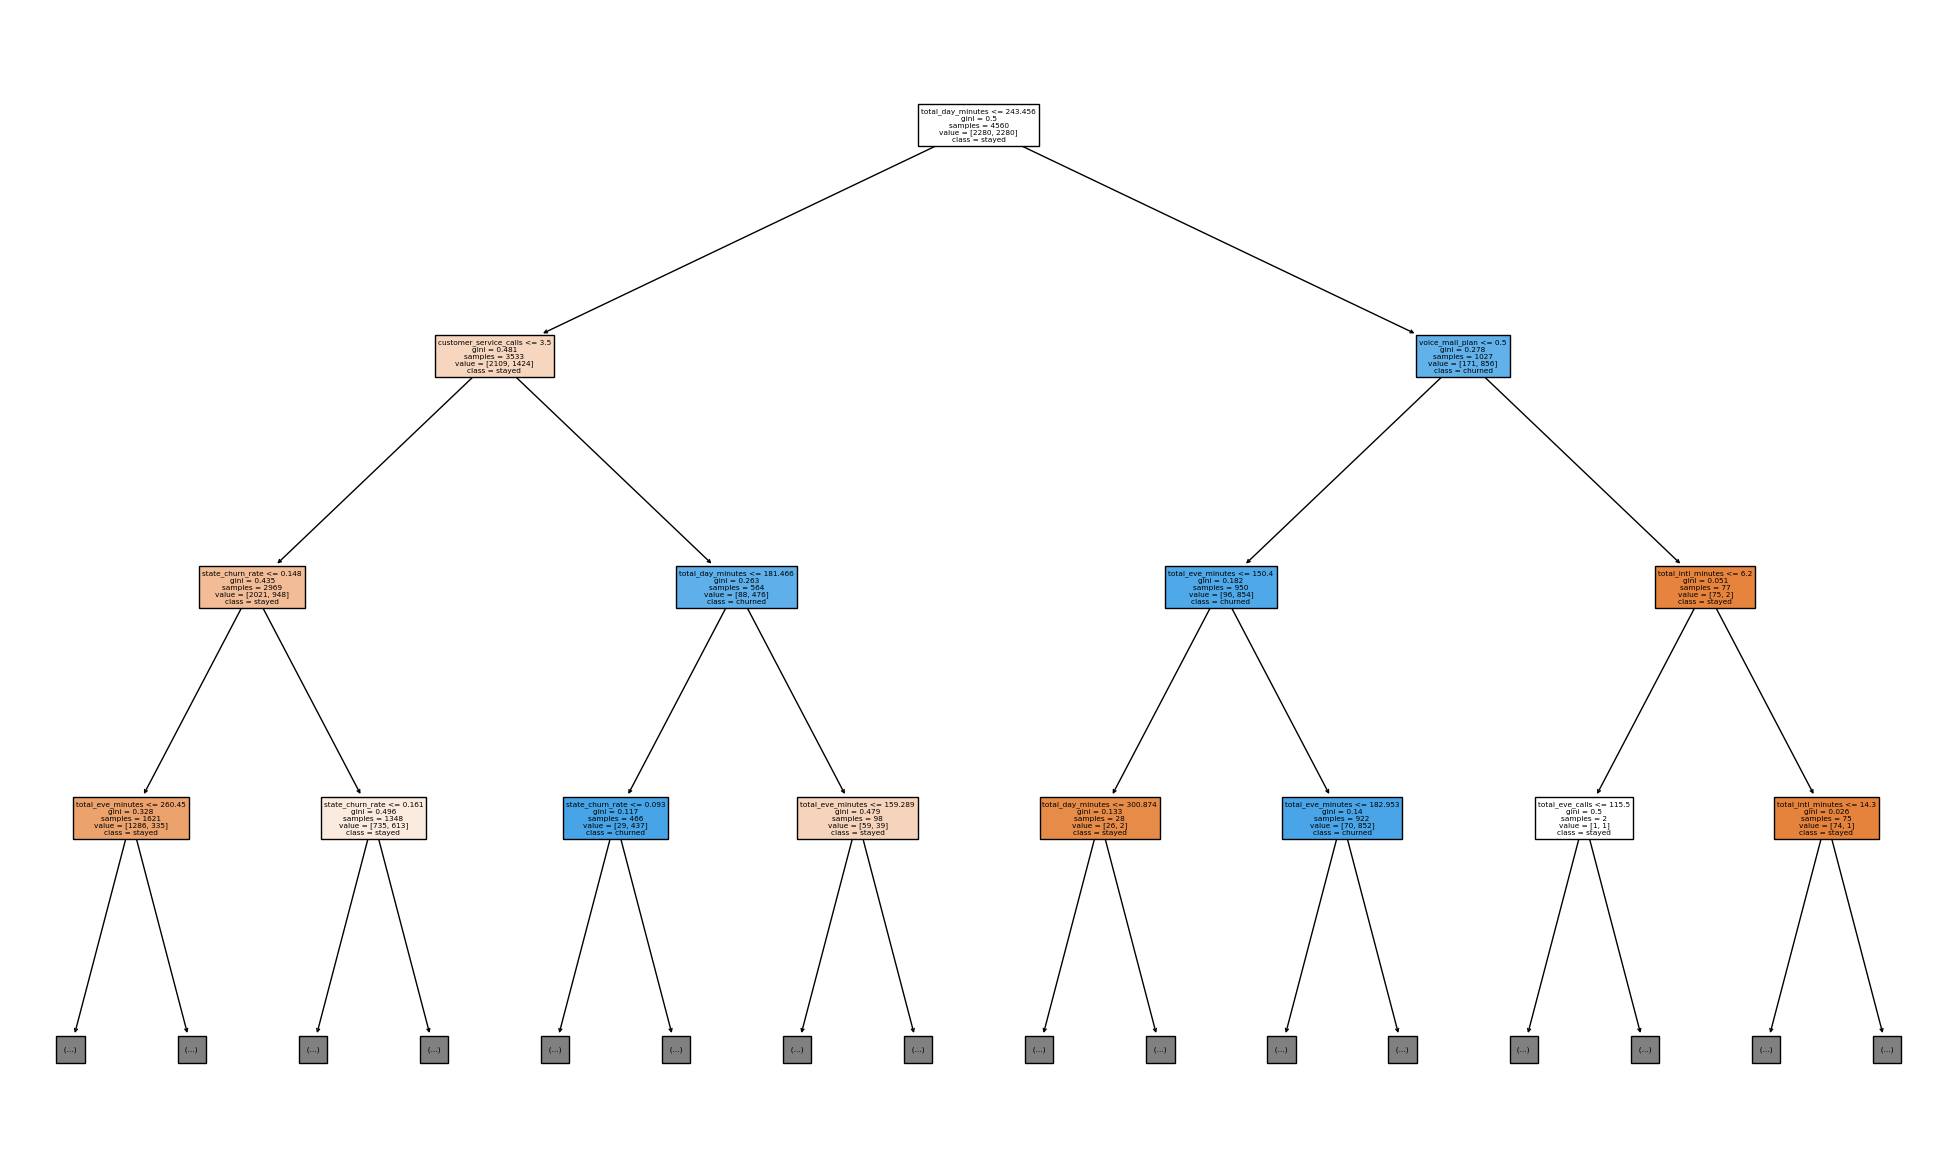

In [19]:
plt.figure(figsize=(25,15))
plot_tree(dt, feature_names=X.columns, class_names=['stayed','churned'], filled=True, max_depth=3)
plt.show()


In [20]:
customer_service_calls = 5
international_plan = 1
total_day_minutes = 250
voice_mail_plan = 0
number_vmail_messages = 0

if customer_service_calls >= 4:
    prediction = "predict churn"
elif international_plan == 1 and total_day_minutes >= 200:
    prediction = "predict churn"
elif voice_mail_plan == 0 and number_vmail_messages == 0:
    prediction = "higher churn risk"
else:
    prediction = "no churn"

print(prediction)

predict churn


rules for the model:

If customer_service_calls ≥ 4 → predict churn.

Else if international_plan = 1 and total_day_minutes ≥ 200 → predict churn.

Else if voice_mail_plan = 0 and number_vmail_messages = 0 → higher churn risk.


II.LOGISTIC REGRESSION COEFFICIENTS

In [21]:
coeffs = pd.Series(lr.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print("Top 5 features by absolute coefficient:")
print(coeffs.head(5))


Top 5 features by absolute coefficient:
voice_mail_plan          -2.126718
number_vmail_messages     1.550486
total_day_minutes         0.776701
customer_service_calls    0.766417
state_churn_rate          0.541223
dtype: float64


In [ ]:
INTERPRETATION


Positive coefficient → increases churn probability ( customer_service_calls, international_plan).

Negative coefficient → decreases churn probability ( voice_mail_plan, total_night_minutes).


7.BUSINESS RECOMMENDATIONS

Based on the models, SyriaTel should:

I.Alert retention team when a customer makes >3 customer service calls in a month.

II.Offer loyalty discounts to customers with an international plan and high daytime minutes (>200 min).

III.Encourage voicemail plan adoption – customers without voicemail churn at a significantly higher rate.

IV.Build a simple probability dashboard – score all active customers weekly using the Logistic Regression model (because it gives well-calibrated probabilities).

V.Experiment with intervention thresholds – instead of 0.5, use a threshold that maximizes savings ( target top 20% of churn scores).
